In [1]:
from datasets import load_dataset

# Load the Cyberbullying dataset
dataset = load_dataset("karthikarunr/Cyberbullying-Toxicity-Tweets")

# Inspect the dataset
print(dataset)

c:\Users\USER\anaconda3\envs\exhibit-2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|██████████| 239465/239465 [00:06<00:00, 37261.63 examples/s]


DatasetDict({
    train: Dataset({
        features: ['Text', 'oh_label', 'cleaned_text', 'tokens', 'processed_text', '__index_level_0__'],
        num_rows: 239465
    })
})


C:\Users\USER\AppData\Local\Temp\ipykernel_5504\1391086680.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


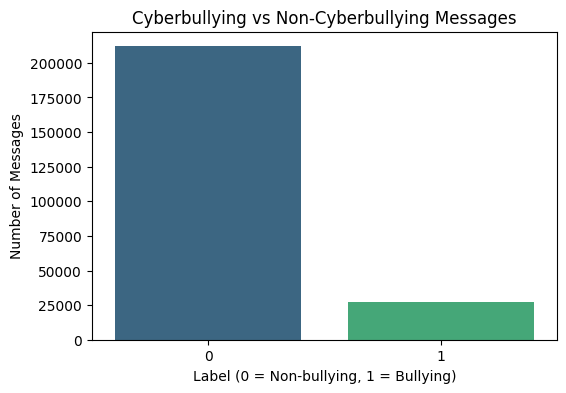

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("cyberbullying_data_labelled.csv")

# If your label column is 'oh_label'
label_counts = df['oh_label'].value_counts()

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Cyberbullying vs Non-Cyberbullying Messages")
plt.xlabel("Label (0 = Non-bullying, 1 = Bullying)")
plt.ylabel("Number of Messages")
plt.show()

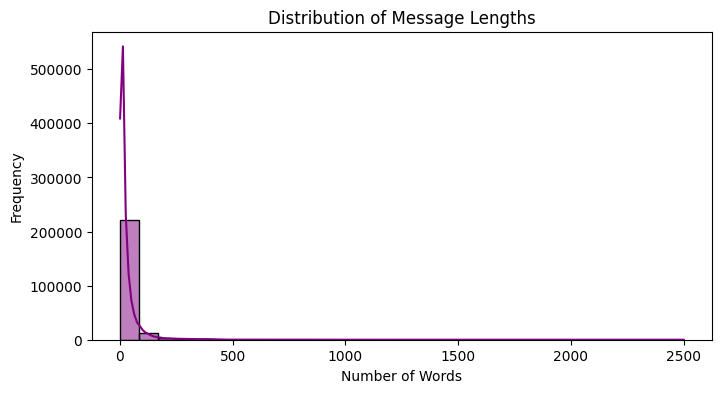

In [2]:
# Compute message lengths
df['message_length'] = df['processed_text'].apply(lambda x: len(str(x).split()))

# Plot distribution
plt.figure(figsize=(8,4))
sns.histplot(df['message_length'], bins=30, kde=True, color="purple")
plt.title("Distribution of Message Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [4]:
!pip install wordcloud


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


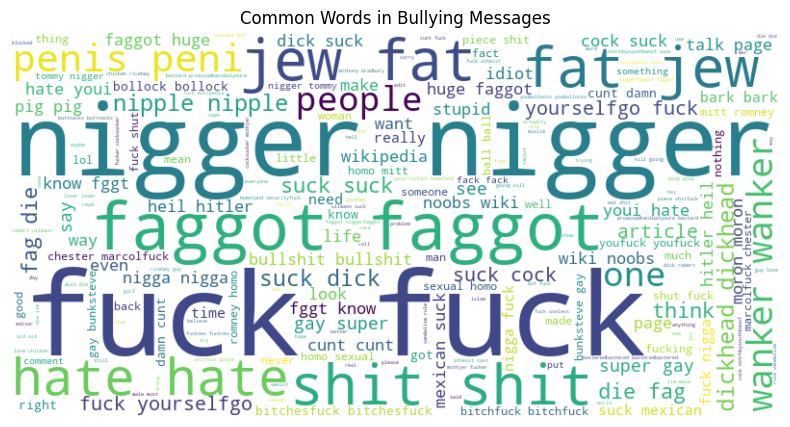

In [5]:
from wordcloud import WordCloud

bullying_text = " ".join(df[df['oh_label']==1]['processed_text'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(bullying_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Common Words in Bullying Messages")
plt.show()